
## Étape 0 : Imports et Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline


# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# MODULE 3 : Clustering — Analyse Non-Supervisée


## 3.1 — Préparation des données (non-supervisée)

In [2]:
# ========== 3.1 PRÉPARATION DES DONNÉES POUR CLUSTERING ==========
print("=== Préparation des données pour le clustering ===")

# On ignore les labels — toutes les features numériques uniquement
# Exclure Prix_Revente qui est trop corrélé avec Conductivite (0.90)
features_cluster = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']
df_clean = pd.read_csv("../data/df_clean2.csv")

X_cluster = df_clean[features_cluster].copy()

# Standardisation obligatoire pour K-Means
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_cluster)

print(f"Matrice pour clustering : {X_clust_scaled.shape}")
print(f"Features utilisées : {features_cluster}")
print("\n Labels IGNORÉS (analyse purement non-supervisée)")

=== Préparation des données pour le clustering ===
Matrice pour clustering : (9724, 5)
Features utilisées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']

 Labels IGNORÉS (analyse purement non-supervisée)


## 3.2 — Méthode du Coude (Elbow) + Silhouette Score



=== Détermination du K optimal ===
k= 2  →  Inertie =   22414.46  |  Silhouette = 0.5557
k= 3  →  Inertie =    8092.32  |  Silhouette = 0.6653
k= 4  →  Inertie =    4696.22  |  Silhouette = 0.6612
k= 5  →  Inertie =    4125.77  |  Silhouette = 0.5536
k= 6  →  Inertie =    3703.99  |  Silhouette = 0.5240
k= 7  →  Inertie =    3408.79  |  Silhouette = 0.5283
k= 8  →  Inertie =    3237.10  |  Silhouette = 0.4167
k= 9  →  Inertie =    2993.22  |  Silhouette = 0.4685
k=10  →  Inertie =    2757.04  |  Silhouette = 0.3323

🔍 Coude détecté (Elbow): k = 4
📊 Meilleur Silhouette: k = 3 (score = 0.6653)

✅ Elbow et Silhouette sont cohérents → k = 4

🎯 K OPTIMAL NATUREL: k = 4


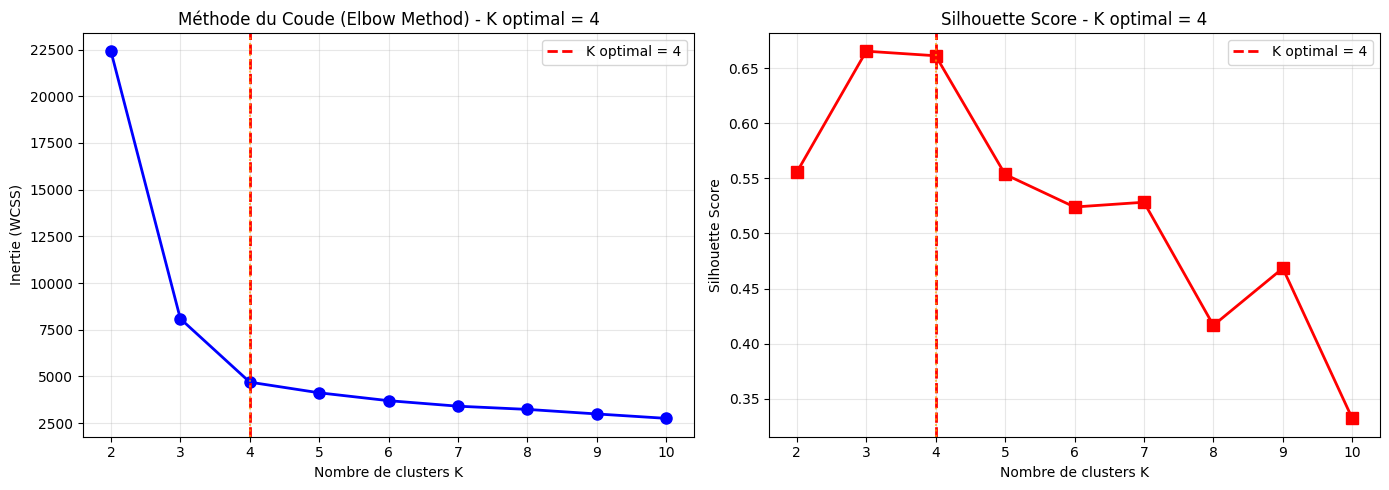


✅ Clustering terminé avec k=4 clusters
Distribution des clusters:
Cluster
0    2514
1    2222
2    2285
3    2703
Name: count, dtype: int64


In [3]:
# ========== 3.2 ELBOW + SILHOUETTE AMÉLIORÉ ==========
print("\n=== Détermination du K optimal ===")

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f"k={k:2d}  →  Inertie = {km.inertia_:10.2f}  |  Silhouette = {sil:.4f}")

# ===== DÉTECTION NATURELLE DU COUDE (Kneedle) =====
# Normalisation pour la méthode Kneedle
x_norm = (np.array(list(K_range)) - min(K_range)) / (max(K_range) - min(K_range))
y_norm = (np.array(inertias) - min(inertias)) / (max(inertias) - min(inertias))
line = (y_norm[-1] - y_norm[0]) * x_norm + y_norm[0]
distances = np.abs(y_norm - line)
elbow_k = K_range[np.argmax(distances)]

# Meilleur k par silhouette
best_k_sil = K_range[np.argmax(silhouette_scores)]
best_sil_score = max(silhouette_scores)

print(f"\n🔍 Coude détecté (Elbow): k = {elbow_k}")
print(f"📊 Meilleur Silhouette: k = {best_k_sil} (score = {best_sil_score:.4f})")

# ===== DÉCISION FINALE NATURELLE =====
# On prend le k du coude si proche du meilleur silhouette, sinon on équilibre
if abs(elbow_k - best_k_sil) <= 1:
    best_k = elbow_k
    print(f"\n✅ Elbow et Silhouette sont cohérents → k = {best_k}")
else:
    # Moyenne pondérée (favorise légèrement le coude)
    best_k = round((elbow_k * 0.6 + best_k_sil * 0.4))
    print(f"\n⚖️ Équilibre entre Elbow (k={elbow_k}) et Silhouette (k={best_k_sil}) → k = {best_k}")

print(f"\n" + "="*60)
print(f"🎯 K OPTIMAL NATUREL: k = {best_k}")
print("="*60)

# Visualisation (Elbow + Silhouette seulement)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[0].axvline(x=4, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].set_title("Méthode du Coude (Elbow Method) - K optimal = " + str(best_k))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette curve
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[1].axvline(x=4, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title("Silhouette Score - K optimal = " + str(best_k))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== K-MEANS FINAL =====
kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_clust_scaled)
df_clean['Cluster'] = clusters

print(f"\n✅ Clustering terminé avec k={best_k} clusters")
print(f"Distribution des clusters:")
print(df_clean['Cluster'].value_counts().sort_index())

## 3.3 — Entraînement K-Means avec K Optimal

In [4]:
# ========== 3.3 ENTRAÎNEMENT K-MEANS ==========
print("\n=== Entraînement K-Means ===")

# Option 1 : Utiliser le K optimal trouvé
OPTIMAL_K_SIL = best_k_sil

# Option 2 : K=4 c
OPTIMAL_K = 4  

print(f"K optimal par Silhouette : {OPTIMAL_K_SIL}")
print(f"K 4  : {OPTIMAL_K}")

# Entraînement avec K=4
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    random_state=42
)
kmeans_final.fit(X_clust_scaled)
cluster_labels = kmeans_final.labels_

print(f"\n K-Means entraîné avec K = {OPTIMAL_K}")
print(f"Inertie finale  : {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_clust_scaled, cluster_labels):.4f}")

# Distribution des clusters
cluster_dist = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nDistribution des clusters (K={OPTIMAL_K}) :")
print(cluster_dist)


=== Entraînement K-Means ===
K optimal par Silhouette : 3
K 4  : 4

 K-Means entraîné avec K = 4
Inertie finale  : 4696.22
Silhouette Score: 0.6612

Distribution des clusters (K=4) :
0    2514
1    2222
2    2285
3    2703
Name: count, dtype: int64


## 3.4 — Visualisation PCA 2D des Clusters


=== Visualisation PCA 2D ===
Variance expliquée — PC1 : 60.7%  |  PC2 : 30.7%
Variance totale expliquée : 91.4%


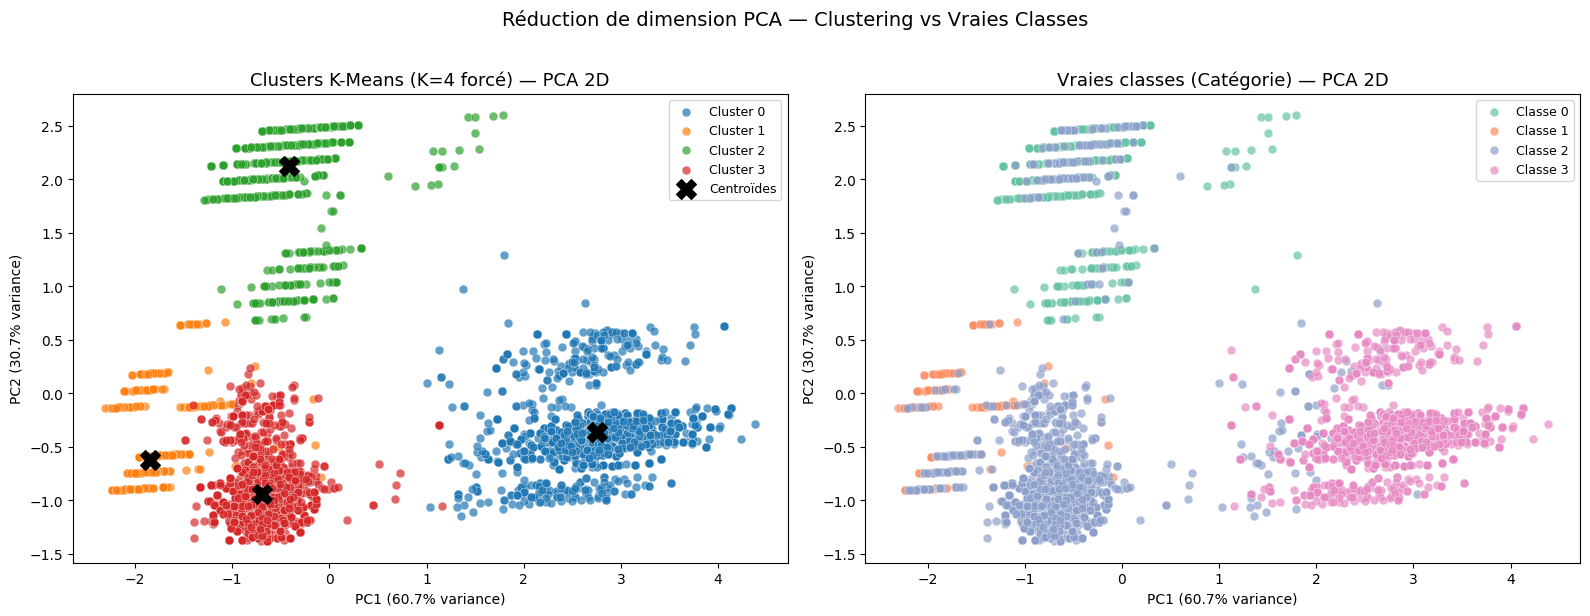

In [5]:
# ========== 3.4 VISUALISATION PCA 2D ==========
print("\n=== Visualisation PCA 2D ===")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Variance expliquée — PC1 : {var_exp[0]*100:.1f}%  |  PC2 : {var_exp[1]*100:.1f}%")
print(f"Variance totale expliquée : {sum(var_exp)*100:.1f}%")

# DataFrame pour visualisation
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels,
    'Vrai_Label': df_clean['Categorie'].values  # comparaison visuelle
})

# Figure principale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 : Clusters K-Means (K=4 forcé)
palette_clusters = sns.color_palette('tab10', OPTIMAL_K)
for k in range(OPTIMAL_K):
    mask = pca_df['Cluster'] == k
    axes[0].scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[palette_clusters[k]],
        label=f'Cluster {k}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )

# Centroïdes
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=200, c='black', zorder=5, label='Centroïdes'
)
axes[0].set_title(f'Clusters K-Means (K={OPTIMAL_K} forcé) — PCA 2D', fontsize=13)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[0].legend(loc='best', fontsize=9)

# Plot 2 : Vraies étiquettes (Catégorie)
n_classes = pca_df['Vrai_Label'].nunique()
palette_labels = sns.color_palette('Set2', n_classes)
for c, color in zip(sorted(pca_df['Vrai_Label'].unique()), palette_labels):
    mask = pca_df['Vrai_Label'] == c
    axes[1].scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[color],
        label=f'Classe {c}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )
axes[1].set_title('Vraies classes (Catégorie) — PCA 2D', fontsize=13)
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[1].legend(loc='best', fontsize=9)

plt.suptitle('Réduction de dimension PCA — Clustering vs Vraies Classes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.5 — Scree Plot PCA (Variance Expliquée)

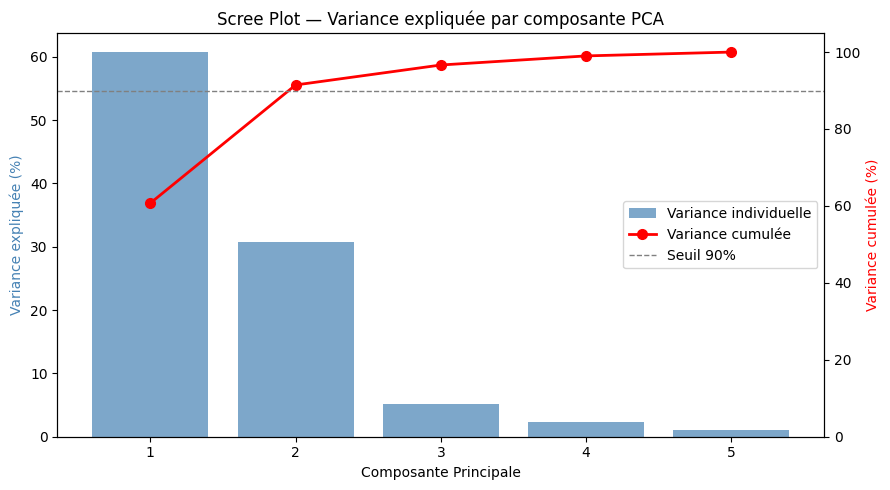

Composantes nécessaires pour 80% de variance : 2
Composantes nécessaires pour 90% de variance : 2
Composantes nécessaires pour 95% de variance : 3


In [6]:
pca_full = PCA(random_state=42)
pca_full.fit(X_clust_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
indvar = pca_full.explained_variance_ratio_ * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

bars = ax1.bar(range(1, len(indvar)+1), indvar,
               color='steelblue', alpha=0.7, label='Variance individuelle')
ax1.set_xlabel('Composante Principale')
ax1.set_ylabel('Variance expliquée (%)', color='steelblue')
ax1.set_xticks(range(1, len(indvar)+1))

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar, 'ro-',
         linewidth=2, markersize=7, label='Variance cumulée')
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, label='Seuil 90%')
ax2.set_ylabel('Variance cumulée (%)', color='red')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Scree Plot — Variance expliquée par composante PCA')
plt.tight_layout()
plt.show()

for threshold in [80, 90, 95]:
    n_comp = (cumvar >= threshold).argmax() + 1
    print(f"Composantes nécessaires pour {threshold}% de variance : {n_comp}")

## 3.6 — Analyse des Clusters

Cette section analyse en profondeur les clusters trouvés :
- Profil moyen de chaque cluster (heatmap + radar chart)
- Distribution des features par cluster (boxplots)
- Comparaison avec les vraies catégories (ARI, matrice de contingence)
- Interprétation métier et labeling des clusters


        ANALYSE APPROFONDIE DES CLUSTERS

── 3.6.1  Profil moyen des clusters ──

Moyennes brutes par cluster :
           Poids   Volume  Conductivite  Opacite  Rigidite
Cluster                                                   
0        181.905  356.331         0.023    0.107     8.866
1         16.337   36.334         0.021    1.000     2.259
2         61.405  120.734         0.504    0.998     8.411
3         30.030   60.808         0.022    0.401     4.089


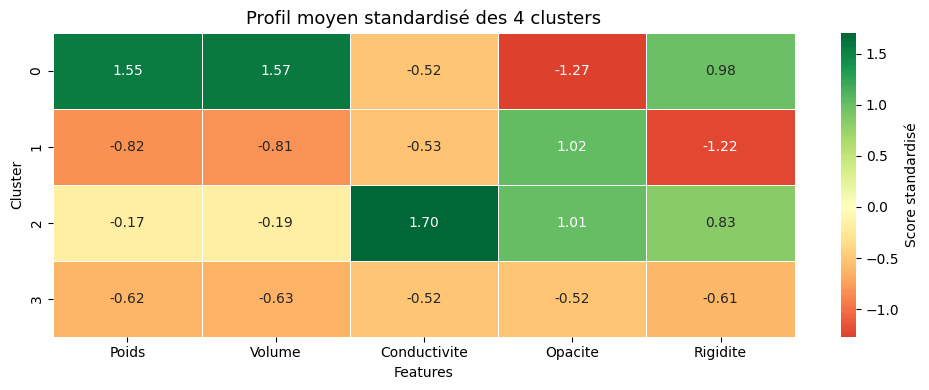


── 3.6.2  Radar Chart — Profil des clusters ──


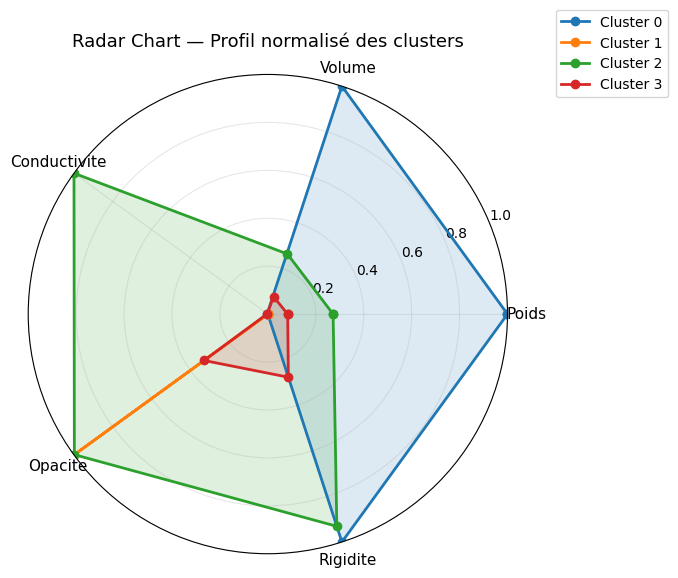


── 3.6.4  Comparaison Clusters vs Vraies Catégories ──

   Adjusted Rand Index (ARI) : 0.8919
   (1.0 = parfaite correspondance | 0 = aléatoire | < 0 = pire que hasard)

Table de contingence (Cluster × Catégorie réelle) :
Categorie_Nom  Carton  Papier  Plastique  Verre   All
Cluster                                              
0                2378       2          0    134  2514
1                   0       0       2104    118  2222
2                   0    2161          0    124  2285
3                   6       0          0   2697  2703
All              2384    2163       2104   3073  9724


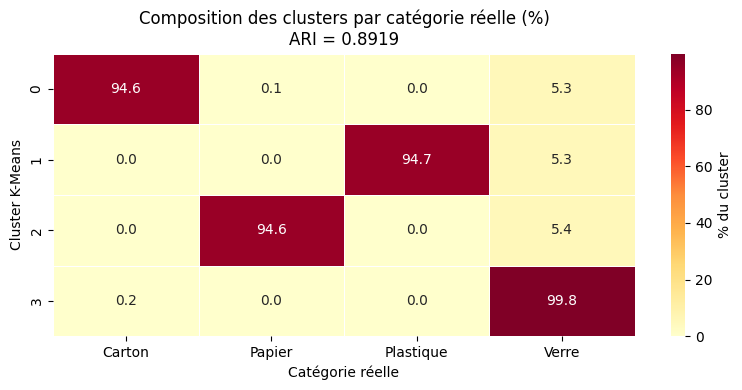


── 3.6.5  Interprétation métier des clusters ──

Résumé par cluster :
         Taille  % dataset Catégorie dominante  % dominante   Poids  Volume  Conductivite  Opacite  Rigidite
Cluster                                                                                                     
0          2514       25.9              Carton         94.6  181.91  356.33          0.02     0.11      8.87
1          2222       22.9           Plastique         94.7   16.34   36.33          0.02     1.00      2.26
2          2285       23.5              Papier         94.6   61.41  120.73          0.50     1.00      8.41
3          2703       27.8               Verre         99.8   30.03   60.81          0.02     0.40      4.09


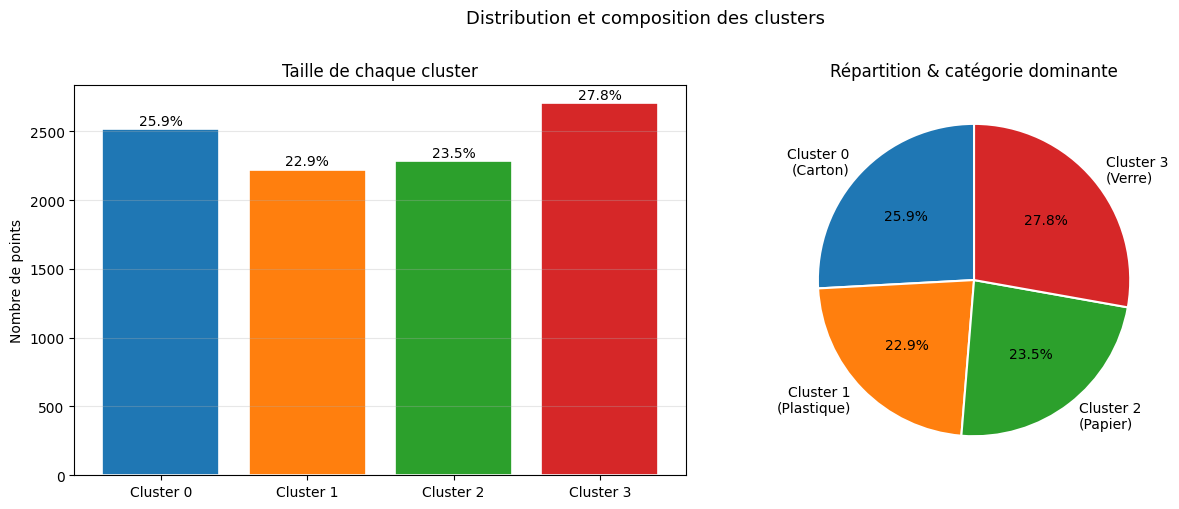


   SYNTHÈSE
  Cluster 0 [ 2514 pts | 25.9%]  → Carton   (94.6%)  | ↑ Volume         ↓ Opacite
  Cluster 1 [ 2222 pts | 22.9%]  → Plastique (94.7%)  | ↑ Opacite        ↓ Rigidite
  Cluster 2 [ 2285 pts | 23.5%]  → Papier   (94.6%)  | ↑ Conductivite   ↓ Volume
  Cluster 3 [ 2703 pts | 27.8%]  → Verre    (99.8%)  | ↑ Opacite        ↓ Volume

  ARI (clusters vs catégories) : 0.8919
  ✅ Les clusters correspondent bien aux vraies catégories


In [7]:
# ========== 3.6 ANALYSE DES CLUSTERS ==========
from sklearn.metrics import adjusted_rand_score, confusion_matrix
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.colors as mcolors

print("=" * 65)
print("        ANALYSE APPROFONDIE DES CLUSTERS")
print("=" * 65)

# ── Synchroniser les labels K-Means finaux dans df_clean ──────────────────
df_clean['Cluster'] = cluster_labels

# ── Correspondance chiffre→nom de catégorie (Categorie 0-3) ───────────────
cat_names = {0: 'Papier', 1: 'Plastique', 2: 'Verre', 3: 'Carton'}
df_clean['Categorie_Nom'] = df_clean['Categorie'].map(cat_names)

# ════════════════════════════════════════════════════════════════════════════
# 3.6.1  PROFIL MOYEN DES CLUSTERS — Heatmap
# ════════════════════════════════════════════════════════════════════════════
print("\n── 3.6.1  Profil moyen des clusters ──")

cluster_profile = df_clean.groupby('Cluster')[features_cluster].mean()
cluster_profile_scaled = pd.DataFrame(
    scaler_clust.transform(cluster_profile),
    index=cluster_profile.index,
    columns=features_cluster
)

print("\nMoyennes brutes par cluster :")
print(cluster_profile.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    cluster_profile_scaled,
    annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, ax=ax, center=0,
    cbar_kws={'label': 'Score standardisé'}
)
ax.set_title(f'Profil moyen standardisé des {OPTIMAL_K} clusters', fontsize=13)
ax.set_xlabel('Features')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 3.6.2  RADAR CHART — Profil de chaque cluster
# ════════════════════════════════════════════════════════════════════════════
print("\n── 3.6.2  Radar Chart — Profil des clusters ──")

# Normaliser les moyennes brutes entre 0 et 1 pour le radar
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
profile_norm = pd.DataFrame(
    mms.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=features_cluster
)

labels_radar = features_cluster
N = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]          # fermer le polygone

palette_r = sns.color_palette('tab10', OPTIMAL_K)
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for k in range(OPTIMAL_K):
    values = profile_norm.loc[k].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=palette_r[k], label=f'Cluster {k}')
    ax.fill(angles, values, alpha=0.15, color=palette_r[k])

ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Radar Chart — Profil normalisé des clusters",
             fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# ════════════════════════════════════════════════════════════════════════════
# 3.6.4  COMPARAISON CLUSTERS vs VRAIES CATÉGORIES
# ════════════════════════════════════════════════════════════════════════════
print("\n── 3.6.4  Comparaison Clusters vs Vraies Catégories ──")

ari = adjusted_rand_score(df_clean['Categorie'], df_clean['Cluster'])
print(f"\n   Adjusted Rand Index (ARI) : {ari:.4f}")
print("   (1.0 = parfaite correspondance | 0 = aléatoire | < 0 = pire que hasard)")

# Table de contingence (Cluster × Catégorie)
contingency = pd.crosstab(
    df_clean['Cluster'],
    df_clean['Categorie_Nom'],
    margins=True
)
print("\nTable de contingence (Cluster × Catégorie réelle) :")
print(contingency.to_string())

# Heatmap de contingence (sans marges)
contingency_pct = pd.crosstab(
    df_clean['Cluster'],
    df_clean['Categorie_Nom'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(8, max(4, OPTIMAL_K)))
sns.heatmap(
    contingency_pct,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '% du cluster'}
)
ax.set_title(
    f'Composition des clusters par catégorie réelle (%)\n'
    f'ARI = {ari:.4f}',
    fontsize=12
)
ax.set_xlabel('Catégorie réelle')
ax.set_ylabel('Cluster K-Means')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 3.6.5  STATISTIQUES & INTERPRÉTATION MÉTIER
# ════════════════════════════════════════════════════════════════════════════
print("\n── 3.6.5  Interprétation métier des clusters ──")

# Taille des clusters
cluster_sizes = df_clean['Cluster'].value_counts().sort_index()
cluster_pct   = (cluster_sizes / len(df_clean) * 100).round(1)

# Catégorie dominante dans chaque cluster
dominant_cat = df_clean.groupby('Cluster')['Categorie_Nom'].agg(
    lambda x: x.value_counts().idxmax()
)
dominant_pct = df_clean.groupby('Cluster')['Categorie_Nom'].agg(
    lambda x: x.value_counts().max() / len(x) * 100
).round(1)

# Résumé
summary = pd.DataFrame({
    'Taille': cluster_sizes,
    '% dataset': cluster_pct,
    'Catégorie dominante': dominant_cat,
    '% dominante': dominant_pct,
})
# Ajouter profil moyen
summary = summary.join(cluster_profile.round(2))
print("\nRésumé par cluster :")
print(summary.to_string())

# ── Graphique taille des clusters ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart taille
bars = axes[0].bar(
    [f'Cluster {k}' for k in range(OPTIMAL_K)],
    cluster_sizes.values,
    color=[palette_r[k] for k in range(OPTIMAL_K)],
    edgecolor='white', linewidth=1.2
)
for bar, pct in zip(bars, cluster_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{pct}%', ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Taille de chaque cluster', fontsize=12)
axes[0].set_ylabel('Nombre de points')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart catégorie dominante
axes[1].pie(
    cluster_sizes.values,
    labels=[f'Cluster {k}\n({dominant_cat[k]})' for k in range(OPTIMAL_K)],
    colors=[palette_r[k] for k in range(OPTIMAL_K)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Répartition & catégorie dominante', fontsize=12)

plt.suptitle('Distribution et composition des clusters', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Message de synthèse ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print("   SYNTHÈSE")
print("=" * 65)
for k in range(OPTIMAL_K):
    top_feat = cluster_profile_scaled.loc[k].idxmax()
    low_feat = cluster_profile_scaled.loc[k].idxmin()
    print(f"  Cluster {k} [{cluster_sizes[k]:5d} pts | {cluster_pct[k]:4.1f}%]  "
          f"→ {dominant_cat[k]:8s} ({dominant_pct[k]:.1f}%)  "
          f"| ↑ {top_feat:<14s} ↓ {low_feat}")
print(f"\n  ARI (clusters vs catégories) : {ari:.4f}")
if ari >= 0.7:
    print("  ✅ Les clusters correspondent bien aux vraies catégories")
elif ari >= 0.4:
    print("  ⚠️  Les clusters capturent partiellement les catégories")
else:
    print("  ℹ️  Les clusters représentent une structure différente des catégories")
print("=" * 65)


## 3.7 — Sous-Clustering à l'intérieur de chaque Cluster

On applique un **K-Means secondaire** dans chacun des 4 clusters principaux.
Le nombre de sous-clusters optimal est détecté automatiquement
par la méthode **Kneedle (Elbow)** combinée au **Silhouette Score**, exactement
comme en 3.2 pour le clustering principal.


     SOUS-CLUSTERING — K-Means Hiérarchique

Cluster 0 (Carton) → 4 sous-clusters  [Silhouette = 0.2838]
  Sub 0-0:   477 pts | {'Carton': 426, 'Verre': 51}
  Sub 0-1:  1178 pts | {'Carton': 1135, 'Verre': 43}
  Sub 0-2:   608 pts | {'Carton': 583, 'Verre': 25}
  Sub 0-3:   251 pts | {'Carton': 234, 'Verre': 15, 'Papier': 2}

Cluster 1 (Plastique) → 4 sous-clusters  [Silhouette = 0.5208]
  Sub 1-0:  1198 pts | {'Plastique': 1138, 'Verre': 60}
  Sub 1-1:   680 pts | {'Plastique': 642, 'Verre': 38}
  Sub 1-2:   205 pts | {'Plastique': 192, 'Verre': 13}
  Sub 1-3:   139 pts | {'Plastique': 132, 'Verre': 7}

Cluster 2 (Papier) → 3 sous-clusters  [Silhouette = 0.3995]
  Sub 2-0:  1085 pts | {'Papier': 1033, 'Verre': 52}
  Sub 2-1:   996 pts | {'Papier': 937, 'Verre': 59}
  Sub 2-2:   204 pts | {'Papier': 191, 'Verre': 13}

Cluster 3 (Verre) → 3 sous-clusters  [Silhouette = 0.3180]
  Sub 3-0:  1547 pts | {'Verre': 1547}
  Sub 3-1:   874 pts | {'Verre': 868, 'Carton': 6}
  Sub 3-2:   282 pts 

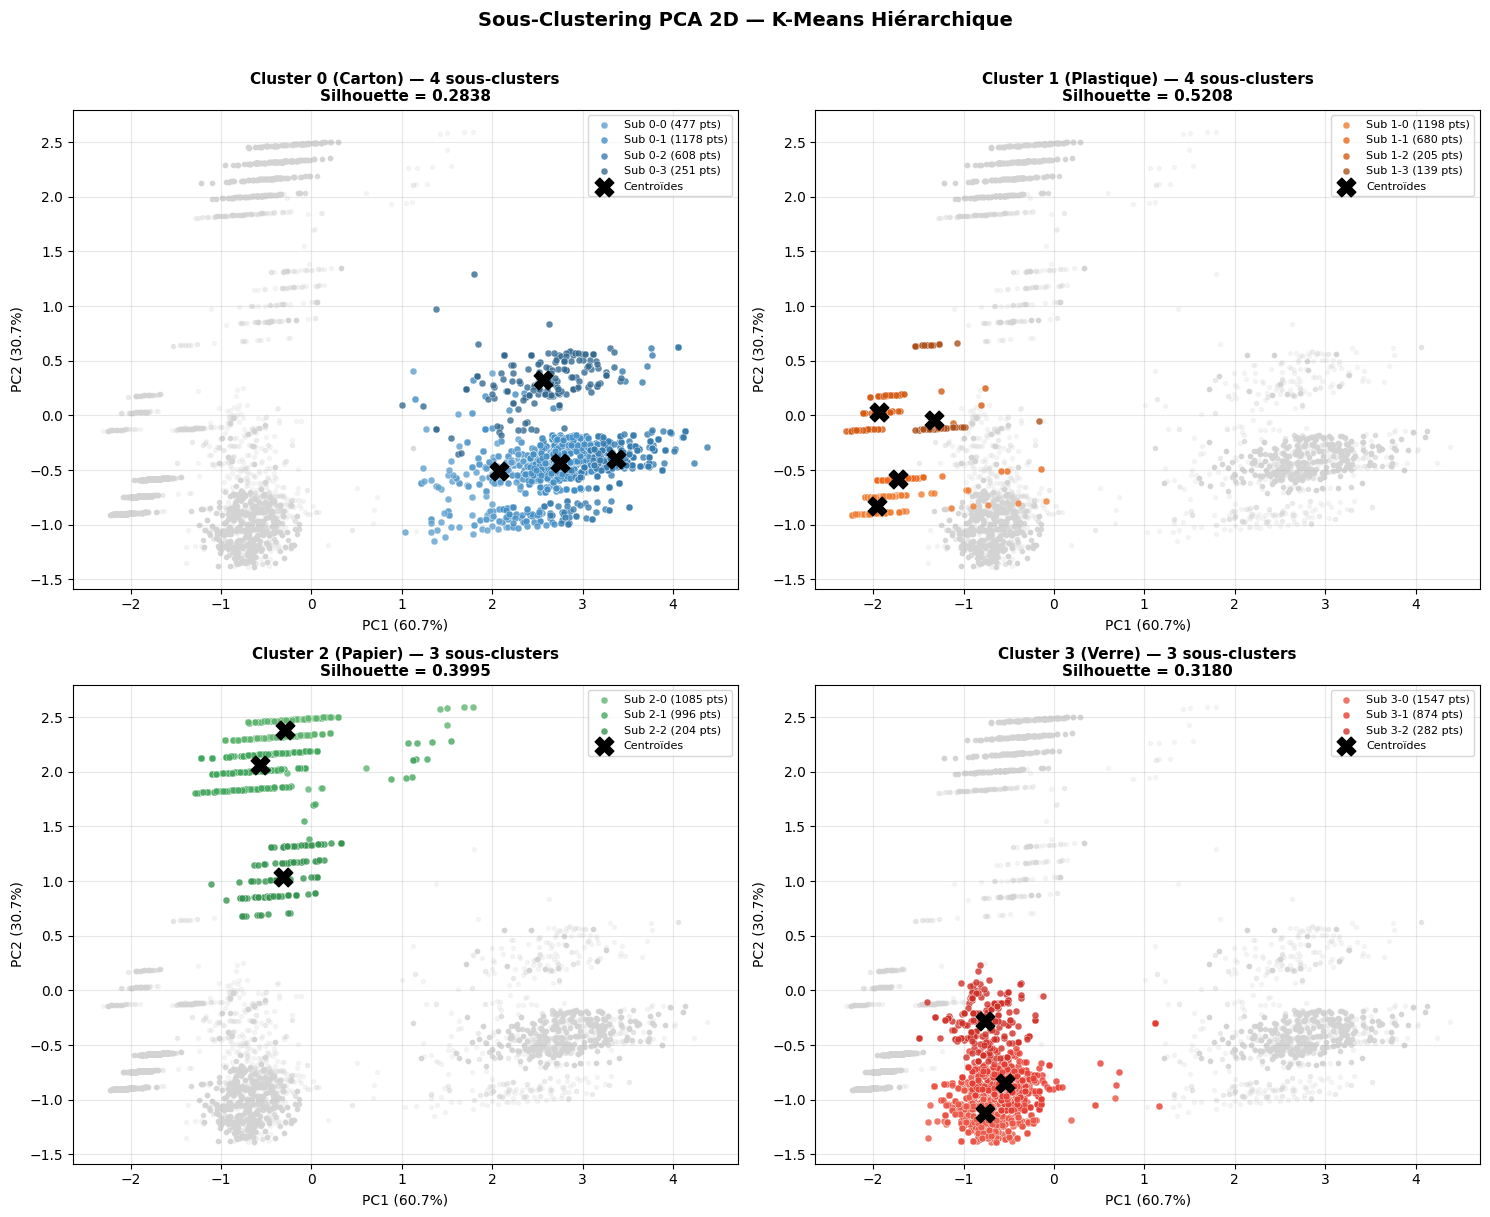

In [8]:
# ========== 3.7 SOUS-CLUSTERING PAR CLUSTER ==========
print("=" * 65)
print("     SOUS-CLUSTERING — K-Means Hiérarchique")
print("=" * 65)

# ── Noms des catégories (réutilisés depuis 3.6) ───────────────────────────
cat_names = {0: 'Papier', 1: 'Plastique', 2: 'Verre', 3: 'Carton'}
df_clean['Categorie_Nom'] = df_clean['Categorie'].map(cat_names)

# ── Fonction : K optimal automatique (Elbow + Silhouette) ─────────────────
def find_optimal_k(X_scaled, k_min=2, k_max=6):
    """Même logique que 3.2 — Kneedle + meilleur Silhouette."""
    k_range = range(k_min, min(k_max + 1, len(X_scaled) // 10))
    if len(k_range) < 2:
        return k_min
    inertias, sil_scores = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_scaled, km.labels_))
    # Kneedle
    ks = np.array(list(k_range))
    y = np.array(inertias)
    x_n = (ks - ks.min()) / (ks.max() - ks.min() + 1e-9)
    y_n = (y  - y.min())  / (y.max()  - y.min()  + 1e-9)
    line = (y_n[-1] - y_n[0]) * x_n + y_n[0]
    elbow_k = int(ks[np.argmax(np.abs(y_n - line))])
    best_sil_k = int(ks[np.argmax(sil_scores)])
    # Décision
    if abs(elbow_k - best_sil_k) <= 1:
        return elbow_k
    return round(elbow_k * 0.6 + best_sil_k * 0.4)

# ── Palette principale ────────────────────────────────────────────────────
palette_main   = sns.color_palette('tab10', OPTIMAL_K)
sub_palettes   = [sns.color_palette('Blues_d',  8),
                  sns.color_palette('Oranges_d', 8),
                  sns.color_palette('Greens_d',  8),
                  sns.color_palette('Reds_d',    8)]

# ── Stockage des résultats ────────────────────────────────────────────────
sub_results = {}   # {cluster_id: {'labels': ..., 'km': ..., 'k': ..., 'sil': ...}}
df_clean['Sub_Cluster'] = -1
df_clean['Sub_Cluster_Global'] = ''  # ex: '0-1' = cluster 0, sous-cluster 1

# ══════════════════════════════════════════════════════════════════════════
# BOUCLE PRINCIPALE — sous-clustering de chaque cluster
# ══════════════════════════════════════════════════════════════════════════
for c_id in range(OPTIMAL_K):
    mask = df_clean['Cluster'] == c_id
    idx  = df_clean.index[mask]
    X_sub = X_clust_scaled[mask.values]

    # K optimal pour ce sous-cluster
    opt_sub_k = find_optimal_k(X_sub, k_min=2, k_max=5)

    km_sub = KMeans(n_clusters=opt_sub_k, init='k-means++',
                    n_init=15, random_state=42)
    sub_labels = km_sub.fit_predict(X_sub)
    sil_sub    = silhouette_score(X_sub, sub_labels)

    df_clean.loc[idx, 'Sub_Cluster'] = sub_labels
    df_clean.loc[idx, 'Sub_Cluster_Global'] = [
        f'{c_id}-{s}' for s in sub_labels
    ]

    sub_results[c_id] = {
        'labels': sub_labels, 'km': km_sub,
        'k': opt_sub_k, 'sil': sil_sub,
        'idx': idx, 'X_sub': X_sub
    }

    cat_dom = df_clean.loc[idx, 'Categorie_Nom'].value_counts().idxmax()
    print(f"\nCluster {c_id} ({cat_dom}) → {opt_sub_k} sous-clusters  "
          f"[Silhouette = {sil_sub:.4f}]")
    for s in range(opt_sub_k):
        s_mask = sub_labels == s
        s_cat  = df_clean.loc[idx[s_mask], 'Categorie_Nom'].value_counts()
        print(f"  Sub {c_id}-{s}: {s_mask.sum():5d} pts | "
              f"{s_cat.to_dict()}")

# ══════════════════════════════════════════════════════════════════════════
# VISUALISATION 1 — PCA 2D : sous-clusters de chaque cluster
# ══════════════════════════════════════════════════════════════════════════
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_clust_scaled)
var2   = pca2.explained_variance_ratio_

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for c_id in range(OPTIMAL_K):
    ax = axes[c_id]
    res = sub_results[c_id]
    idx = res['idx']
    pca_sub = X_pca2[df_clean['Cluster'] == c_id]
    sub_pal = sub_palettes[c_id]

    # Points en gris pour les autres clusters (contexte)
    other_mask = df_clean['Cluster'] != c_id
    ax.scatter(X_pca2[other_mask, 0], X_pca2[other_mask, 1],
               c='lightgrey', s=8, alpha=0.2, zorder=1)

    # Sous-clusters colorés
    for s in range(res['k']):
        s_mask = res['labels'] == s
        ax.scatter(pca_sub[s_mask, 0], pca_sub[s_mask, 1],
                   c=[sub_pal[2 + s]], s=25, alpha=0.8,
                   label=f'Sub {c_id}-{s} ({s_mask.sum()} pts)',
                   zorder=2, edgecolors='white', linewidths=0.3)

    # Centroïdes sous-clusters
    centroids_s = pca2.transform(res['km'].cluster_centers_)
    ax.scatter(centroids_s[:, 0], centroids_s[:, 1],
               marker='X', s=180, c='black', zorder=5, label='Centroïdes')

    cat_dom = df_clean.loc[idx, 'Categorie_Nom'].value_counts().idxmax()
    ax.set_title(
        f'Cluster {c_id} ({cat_dom}) — {res["k"]} sous-clusters\n'
        f'Silhouette = {res["sil"]:.4f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel(f'PC1 ({var2[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var2[1]*100:.1f}%)')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Sous-Clustering PCA 2D — K-Means Hiérarchique',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
